# Multi-Disease Risk Assessment Using Probabilistic Graphical Models

**Course:** Probabilistic Graphical Models (CSE756)  
**Student:** Shimul Mandal Tamo | ID: 22166046  
**Instructor:** Ipshita Bonhi Upoma (IBU)

---

## Project Overview

This notebook implements a Multi-Disease Risk Assessment framework using Probabilistic Graphical Models (PGMs).  
We move beyond single-disease black-box predictions toward **interpretable causal reasoning** across two datasets:

| Dataset | Disease | Records |
|---|---|---|
| Pima Indians Diabetes | Diabetes | 768 |
| Cardiovascular Disease | Cardio Disease | 70,000 |

###  Roadmap
```
Step 1 → Install & Import Libraries
Step 2 → Load & Explore Datasets (EDA)
Step 3 → Data Preprocessing & Feature Engineering
Step 4 → Baseline Model: Naive Bayes Classifier
Step 5 → Bayesian Network (Structure + Parameter Learning)
Step 6 → Probabilistic Inference (What-If Queries)
Step 7 → Model Evaluation & Comparison
Step 8 → Multi-Disease Risk Score (Combined Inference)
```

---
## Step 1: Install & Import Libraries

In [1]:
# Install pgmpy – the core library for Bayesian Networks
!pip install pgmpy -q

print('pgmpy installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 9.1 MB/s eta 0:00:00
pgmpy installed


In [3]:
# ── Core libraries ──────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = sns.color_palette('muted')

# ── Sklearn ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import KBinsDiscretizer, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer

# ── PGM (pgmpy) ──────────────────────────────────────────────
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import (MaximumLikelihoodEstimator,
                               BayesianEstimator,
                               HillClimbSearch)

# Updated robust import for BicScore
# Robust BicScore import
try:
    from pgmpy.estimators import BicScore
except ImportError:
    try:
        from pgmpy.estimators import BIC as BicScore
    except ImportError:
        from pgmpy.estimators import K2Score as BicScore
        print("ℹ️ Using K2Score instead of BicScore")

from pgmpy.inference import VariableElimination



# ── Graph drawing ────────────────────────────────────────────
import networkx as nx

print(' All libraries loaded successfully')

 All libraries loaded successfully


---
## Step 2: Load & Explore Datasets (EDA)

> **Upload both CSV files** when prompted, or place them in the same folder as this notebook.

In [4]:
# ── 2.1  Load Datasets ─────────────────────────────────────────


diabetes_df  = pd.read_csv('diabetes.csv')
cardio_df    = pd.read_csv('cardio_train.csv', sep=';')   # semicolon-separated

print(f'Diabetes dataset  : {diabetes_df.shape[0]:,} rows × {diabetes_df.shape[1]} cols')
print(f'Cardio   dataset  : {cardio_df.shape[0]:,} rows × {cardio_df.shape[1]} cols')

Diabetes dataset  : 768 rows × 9 cols
Cardio   dataset  : 70,000 rows × 13 cols


In [6]:
# ── 2.2  Quick look at Diabetes dataset ───────────────────────
print('=== Diabetes Dataset ===')
display(diabetes_df.head())
print('\nData Types & Nulls:')
display(diabetes_df.info())

=== Diabetes Dataset ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Data Types & Nulls:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

In [7]:
# ── 2.3  Quick look at Cardio dataset ─────────────────────────
print('=== Cardio Dataset ===')
display(cardio_df.head())
print('\nData Types & Nulls:')
display(cardio_df.info())

=== Cardio Dataset ===


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0



Data Types & Nulls:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


None

In [ ]:
# ── 2.4  Basic Statistics ──────────────────────────────────────
print('=== Diabetes Descriptive Stats ===')
display(diabetes_df.describe().round(2))

=== Diabetes Descriptive Stats ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [8]:
print('=== Cardio Descriptive Stats ===')
display(cardio_df.describe().round(2))

=== Cardio Descriptive Stats ===


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.0,70000.0
mean,49972.42,19468.87,1.35,164.36,74.21,128.82,96.63,1.37,1.23,0.09,0.05,0.8,0.5
std,28851.30,2467.25,0.48,8.21,14.40,154.01,188.47,0.68,0.57,0.28,0.23,0.4,0.5
min,0.00,10798.00,1.00,55.00,10.00,-150.00,-70.00,1.00,1.00,0.00,0.00,0.0,0.0
25%,25006.75,17664.00,1.00,159.00,65.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0
50%,50001.50,19703.00,1.00,165.00,72.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0
75%,74889.25,21327.00,2.00,170.00,82.00,140.00,90.00,2.00,1.00,0.00,0.00,1.0,1.0
max,99999.00,23713.00,2.00,250.00,200.00,16020.00,11000.00,3.00,3.00,1.00,1.00,1.0,1.0


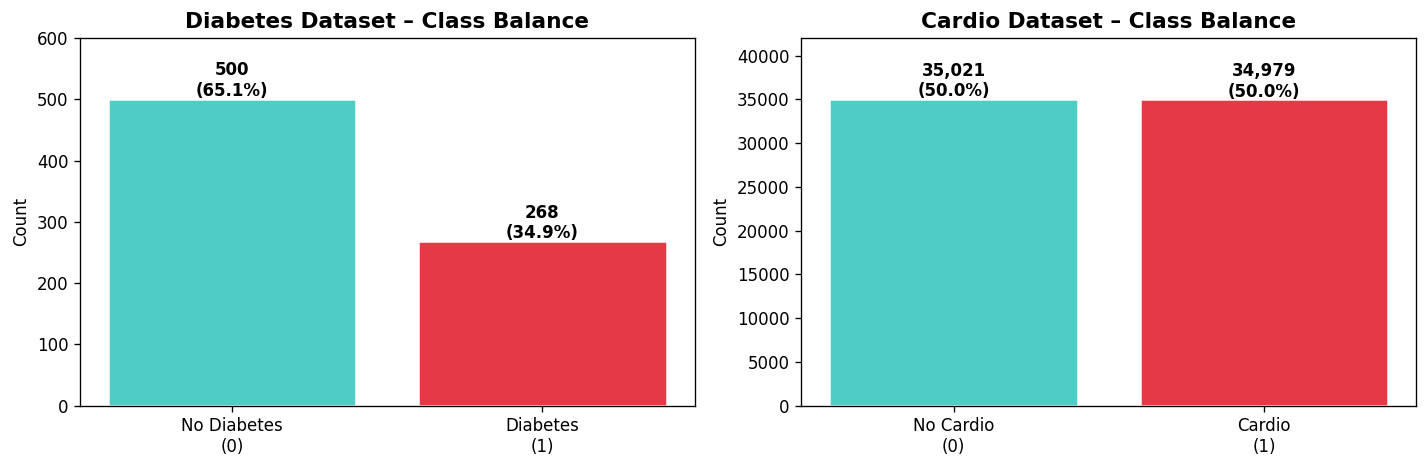

Class distribution plotted


In [9]:
# ── 2.5  Class Distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Diabetes
d_counts = diabetes_df['Outcome'].value_counts()
axes[0].bar(['No Diabetes\n(0)', 'Diabetes\n(1)'], d_counts.values,
            color=['#4ECDC4', '#E63946'], edgecolor='white', linewidth=1.5)
for i, v in enumerate(d_counts.values):
    axes[0].text(i, v + 5, f'{v}\n({v/len(diabetes_df)*100:.1f}%)',
                 ha='center', fontweight='bold')
axes[0].set_title('Diabetes Dataset – Class Balance', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 600)

# Cardio
c_counts = cardio_df['cardio'].value_counts()
axes[1].bar(['No Cardio\n(0)', 'Cardio\n(1)'], c_counts.values,
            color=['#4ECDC4', '#E63946'], edgecolor='white', linewidth=1.5)
for i, v in enumerate(c_counts.values):
    axes[1].text(i, v + 300, f'{v:,}\n({v/len(cardio_df)*100:.1f}%)',
                 ha='center', fontweight='bold')
axes[1].set_title('Cardio Dataset – Class Balance', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, 42000)

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()
print('Class distribution plotted')

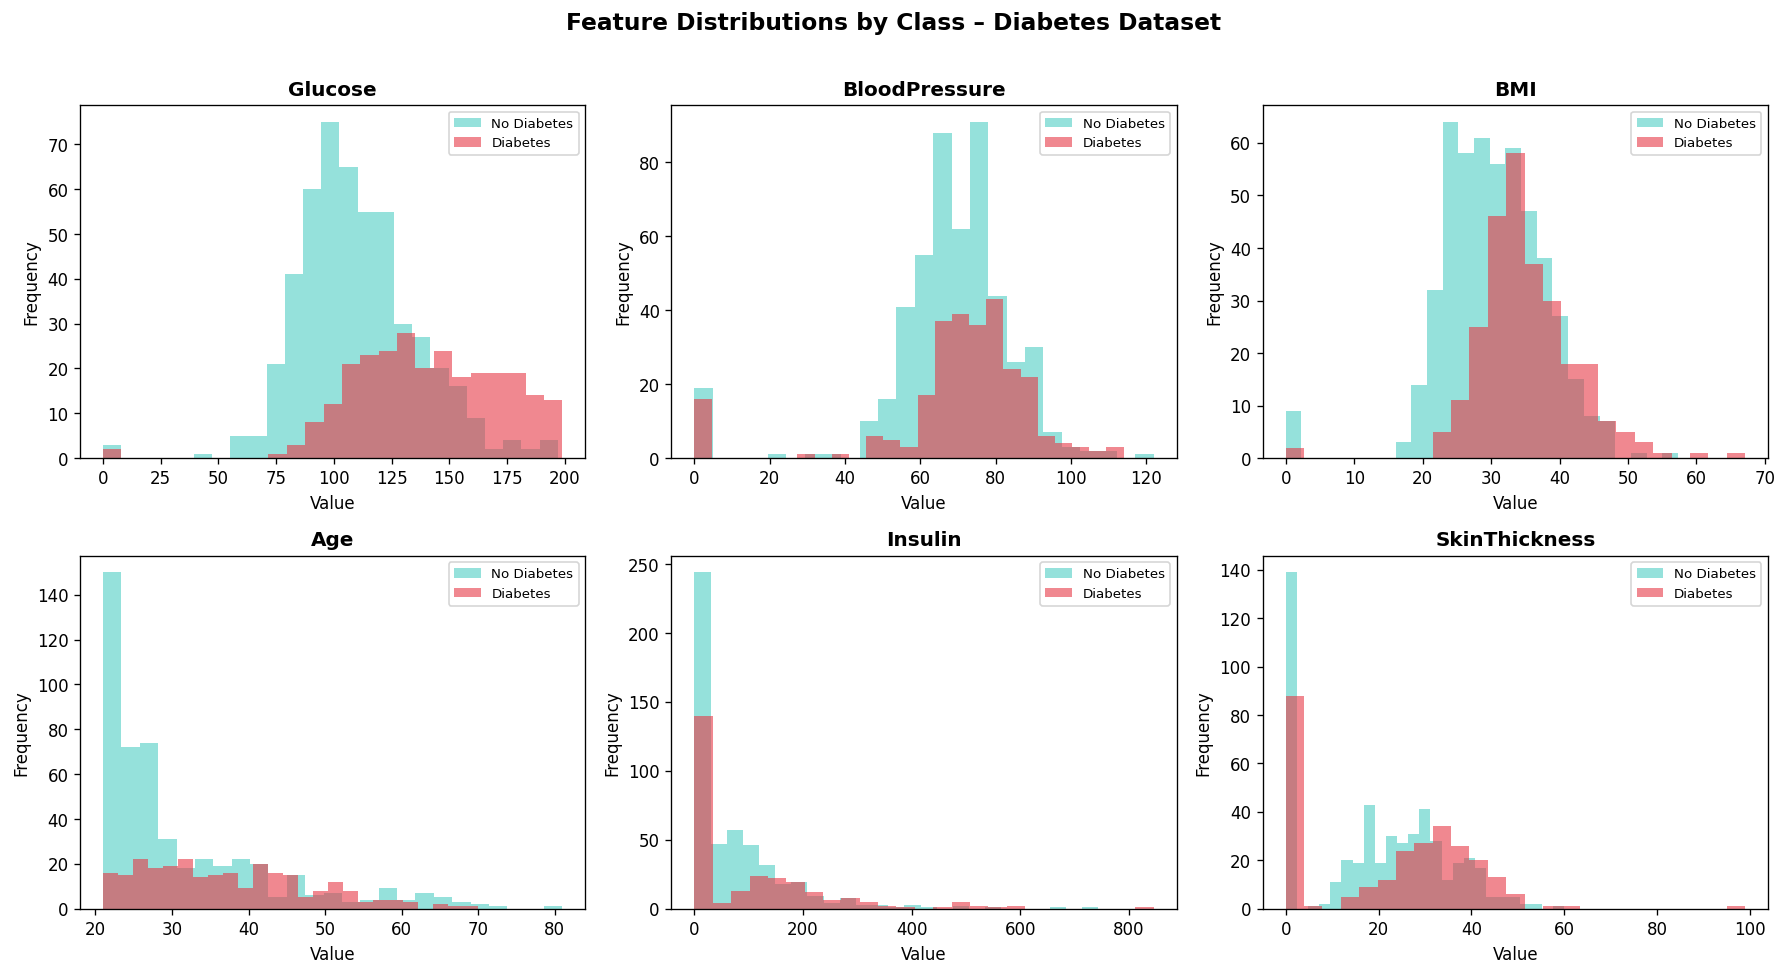

In [10]:
# ── 2.6  Feature Distributions – Diabetes ─────────────────────
features_d = ['Glucose', 'BloodPressure', 'BMI', 'Age', 'Insulin', 'SkinThickness']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_d):
    for label, color in zip([0, 1], ['#4ECDC4', '#E63946']):
        axes[i].hist(diabetes_df[diabetes_df['Outcome'] == label][feat],
                     bins=25, alpha=0.6, color=color,
                     label='No Diabetes' if label == 0 else 'Diabetes')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions by Class – Diabetes Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('diabetes_distributions.png', bbox_inches='tight')
plt.show()

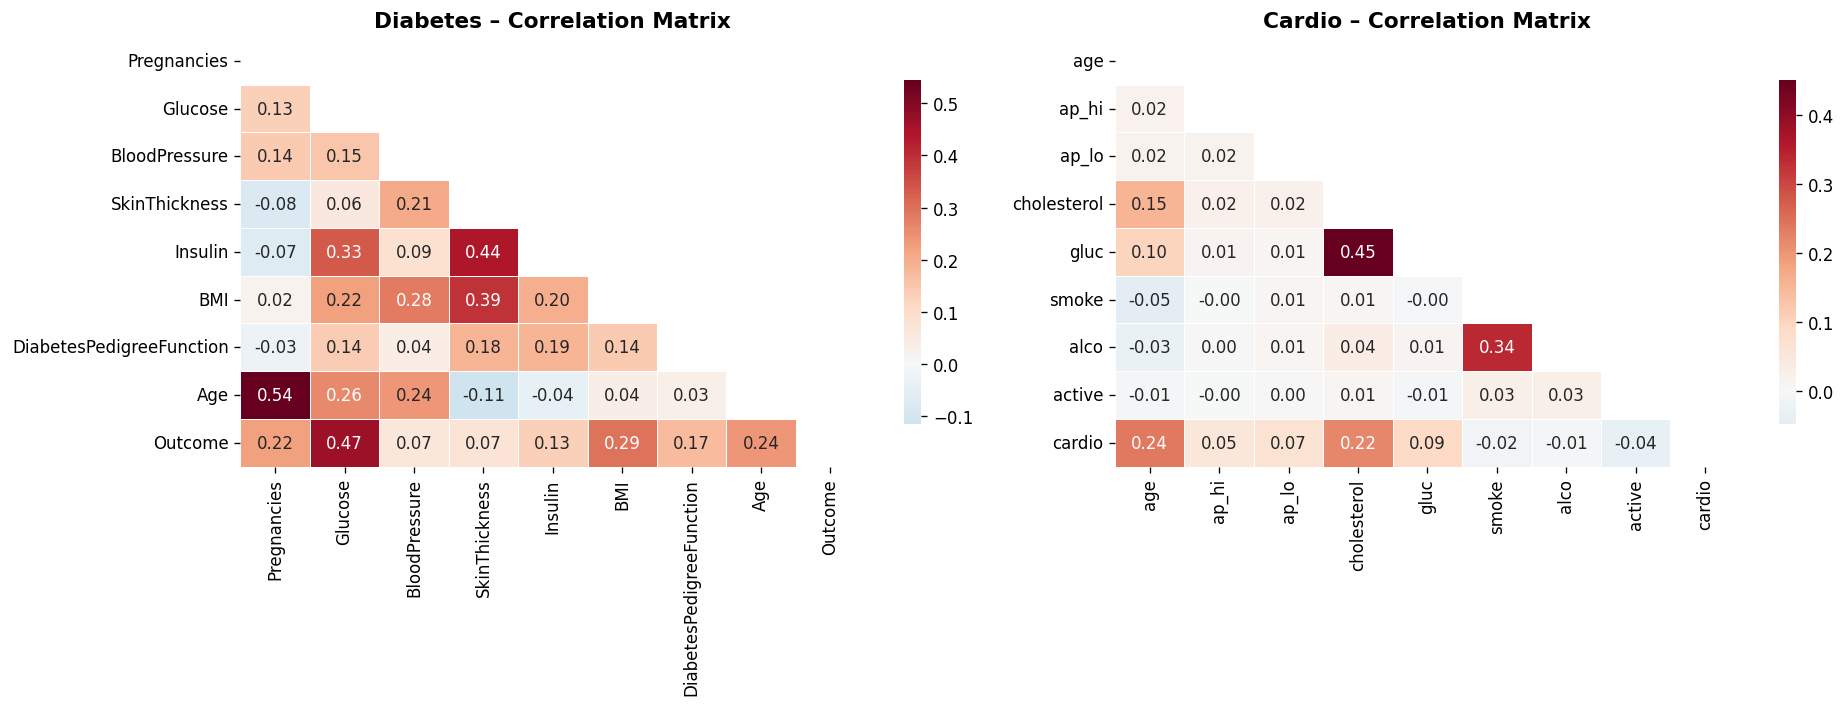

In [11]:
# ── 2.7  Correlation Heatmaps ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Diabetes
corr_d = diabetes_df.corr()
mask = np.triu(np.ones_like(corr_d, dtype=bool))
sns.heatmap(corr_d, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[0], mask=mask,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title('Diabetes – Correlation Matrix', fontsize=13, fontweight='bold')

# Cardio (select numeric cols)
cardio_num = cardio_df[['age', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
                         'smoke', 'alco', 'active', 'cardio']].copy()
corr_c = cardio_num.corr()
mask_c = np.triu(np.ones_like(corr_c, dtype=bool))
sns.heatmap(corr_c, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[1], mask=mask_c,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[1].set_title('Cardio – Correlation Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_heatmaps.png', bbox_inches='tight')
plt.show()

---
## 🔧 Step 3: Data Preprocessing & Feature Engineering

In [14]:
# ── 3.1  Diabetes – Handle impossible zeros ────────────────────
# Glucose, BloodPressure, SkinThickness, Insulin, BMI cannot be 0
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Zero counts before imputation:')
for col in zero_cols:
    n_zeros = (diabetes_df[col] == 0).sum()
    print(f'  {col:25s}: {n_zeros} zeros ({n_zeros/len(diabetes_df)*100:.1f}%)')

diabetes_clean = diabetes_df.copy()
for col in zero_cols:
    diabetes_clean[col] = diabetes_clean[col].replace(0, np.nan)

# Median imputation (robust to outliers)
imputer = SimpleImputer(strategy='median')
diabetes_clean[zero_cols] = imputer.fit_transform(diabetes_clean[zero_cols])

print('\nZeros replaced with median values')
print(f'Remaining nulls: {diabetes_clean.isnull().sum().sum()}')

Zero counts before imputation:
  Glucose                  : 5 zeros (0.7%)
  BloodPressure            : 35 zeros (4.6%)
  SkinThickness            : 227 zeros (29.6%)
  Insulin                  : 374 zeros (48.7%)
  BMI                      : 11 zeros (1.4%)

Zeros replaced with median values
Remaining nulls: 0


In [15]:
# ── 3.2  Cardio – Feature Engineering ────────────────────────
cardio_clean = cardio_df.copy()

# Convert age from days → years
cardio_clean['age_years'] = (cardio_clean['age'] / 365.25).round(0).astype(int)

# Derive BMI from height & weight
cardio_clean['bmi'] = (cardio_clean['weight'] /
                       (cardio_clean['height'] / 100) ** 2).round(1)

# Remove physiologically impossible blood pressure values
cardio_clean = cardio_clean[
    (cardio_clean['ap_hi'] >= 80)  & (cardio_clean['ap_hi'] <= 250) &
    (cardio_clean['ap_lo'] >= 40)  & (cardio_clean['ap_lo'] <= 150) &
    (cardio_clean['ap_hi'] > cardio_clean['ap_lo'])
]

# Drop id and raw age/height/weight (derived features kept)
cardio_clean.drop(columns=['id', 'age', 'height', 'weight'], inplace=True)

print(f'Cardio rows after cleaning: {len(cardio_clean):,} (removed {len(cardio_df)-len(cardio_clean):,} outliers)')
display(cardio_clean.head(3))

Cardio rows after cleaning: 68,662 (removed 1,338 outliers)


,gender,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
0,2,110,80,1,1,0,0,1,0,50,22.0
1,1,140,90,3,1,0,0,1,1,55,34.9
2,1,130,70,3,1,0,0,0,1,52,23.5


In [17]:
# ── 3.3  Discretisation (required for Bayesian Network) ───────
# Bayesian Networks work with discrete states.
# We bin continuous features into interpretable categories.

def discretize_diabetes(df):
    d = df.copy()
    # Glucose: Normal <100, Pre-diabetic 100-125, Diabetic >=126
    d['Glucose_cat']  = pd.cut(d['Glucose'],
                                bins=[0, 99, 125, 500],
                                labels=['Normal', 'Pre-Diabetic', 'Diabetic'])
    # Blood Pressure
    d['BP_cat']       = pd.cut(d['BloodPressure'],
                                bins=[0, 79, 89, 300],
                                labels=['Normal', 'Elevated', 'High'])
    # BMI
    d['BMI_cat']      = pd.cut(d['BMI'],
                                bins=[0, 18.4, 24.9, 29.9, 100],
                                labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
    # Age
    d['Age_cat']      = pd.cut(d['Age'],
                                bins=[0, 30, 45, 60, 100],
                                labels=['Young', 'Middle', 'Senior', 'Elderly'])
    # Insulin
    d['Insulin_cat']  = pd.cut(d['Insulin'],
                                bins=[0, 15, 166, 10000],
                                labels=['Low', 'Normal', 'High'])
    # Diabetes Pedigree
    d['DPF_cat']      = pd.cut(d['DiabetesPedigreeFunction'],
                                bins=[0, 0.4, 0.8, 10],
                                labels=['Low', 'Moderate', 'High'])
    # Target
    d['Outcome_cat']  = d['Outcome'].map({0: 'No_Diabetes', 1: 'Diabetes'})
    return d

def discretize_cardio(df):
    d = df.copy()
    # Age
    d['Age_cat']   = pd.cut(d['age_years'],
                             bins=[0, 40, 55, 70, 100],
                             labels=['Young', 'Middle', 'Senior', 'Elderly'])
    # Systolic BP
    d['SBP_cat']   = pd.cut(d['ap_hi'],
                             bins=[0, 119, 139, 180, 300],
                             labels=['Normal', 'Elevated', 'High', 'Crisis'])
    # Diastolic BP
    d['DBP_cat']   = pd.cut(d['ap_lo'],
                             bins=[0, 79, 89, 120, 200],
                             labels=['Normal', 'Elevated', 'High', 'Crisis'])
    # BMI
    d['BMI_cat']   = pd.cut(d['bmi'],
                             bins=[0, 18.4, 24.9, 29.9, 100],
                             labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
    # Cholesterol: 1=normal, 2=above, 3=well above
    d['Chol_cat']  = d['cholesterol'].map({1: 'Normal', 2: 'Above_Normal', 3: 'High'})
    # Glucose: 1=normal, 2=above, 3=well above
    d['Gluc_cat']  = d['gluc'].map({1: 'Normal', 2: 'Above_Normal', 3: 'High'})
    # Target
    d['Cardio_cat'] = d['cardio'].map({0: 'No_Cardio', 1: 'Cardio'})
    return d

diabetes_disc = discretize_diabetes(diabetes_clean)
cardio_disc   = discretize_cardio(cardio_clean)

print('Discretisation complete')
print('\nDiabetes categories:')
for col in ['Glucose_cat', 'BP_cat', 'BMI_cat', 'Age_cat']:
    print(f'  {col}: {diabetes_disc[col].unique().tolist()}')

Discretisation complete

Diabetes categories:
  Glucose_cat: ['Diabetic', 'Normal', 'Pre-Diabetic']
  BP_cat: ['Normal', 'High', 'Elevated']
  BMI_cat: ['Obese', 'Overweight', 'Normal', 'Underweight']
  Age_cat: ['Senior', 'Middle', 'Young', 'Elderly']


In [19]:
# ── 3.4  Train / Test Split ───────────────────────────────────
# ─── Diabetes (continuous features for Naive Bayes) ───────────
X_d = diabetes_clean.drop(columns=['Outcome'])
y_d = diabetes_clean['Outcome']
X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42, stratify=y_d)

# ─── Cardio (continuous features for Naive Bayes) ────────────
cardio_feat = ['age_years', 'gender', 'ap_hi', 'ap_lo', 'bmi',
               'cholesterol', 'gluc', 'smoke', 'alco', 'active']
X_c = cardio_clean[cardio_feat]
y_c = cardio_clean['cardio']
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c)

print(f'Diabetes  – Train: {len(X_d_train):,} | Test: {len(X_d_test):,}')
print(f'Cardio    – Train: {len(X_c_train):,} | Test: {len(X_c_test):,}')

Diabetes  – Train: 614 | Test: 154
Cardio    – Train: 54,929 | Test: 13,733


---
## Step 4: Baseline Model – Gaussian Naïve Bayes

Naïve Bayes is the natural first PGM: it models P(Class | Features) using Bayes' theorem, assuming **conditional independence** among features given the class label. This serves as our interpretable baseline.

In [20]:
# ── 4.1  Train Naïve Bayes on both datasets ──────────────────
gnb_d = GaussianNB()
gnb_d.fit(X_d_train, y_d_train)
y_d_pred = gnb_d.predict(X_d_test)
y_d_prob = gnb_d.predict_proba(X_d_test)[:, 1]

gnb_c = GaussianNB()
gnb_c.fit(X_c_train, y_c_train)
y_c_pred = gnb_c.predict(X_c_test)
y_c_prob = gnb_c.predict_proba(X_c_test)[:, 1]

print('=== Naïve Bayes – Diabetes ===')
print(f"Accuracy : {accuracy_score(y_d_test, y_d_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_d_test, y_d_prob):.4f}")
print(classification_report(y_d_test, y_d_pred,
                             target_names=['No Diabetes', 'Diabetes']))

print('\n=== Naïve Bayes – Cardio ===')
print(f"Accuracy : {accuracy_score(y_c_test, y_c_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_c_test, y_c_prob):.4f}")
print(classification_report(y_c_test, y_c_pred,
                             target_names=['No Cardio', 'Cardio']))

=== Naïve Bayes – Diabetes ===
Accuracy : 0.7013
ROC-AUC  : 0.7646
              precision    recall  f1-score   support

 No Diabetes       0.79      0.74      0.76       100
    Diabetes       0.57      0.63      0.60        54

    accuracy                           0.70       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.70      0.70       154


=== Naïve Bayes – Cardio ===
Accuracy : 0.7159
ROC-AUC  : 0.7801
              precision    recall  f1-score   support

   No Cardio       0.68      0.82      0.75      6939
      Cardio       0.77      0.61      0.68      6794

    accuracy                           0.72     13733
   macro avg       0.73      0.71      0.71     13733
weighted avg       0.73      0.72      0.71     13733



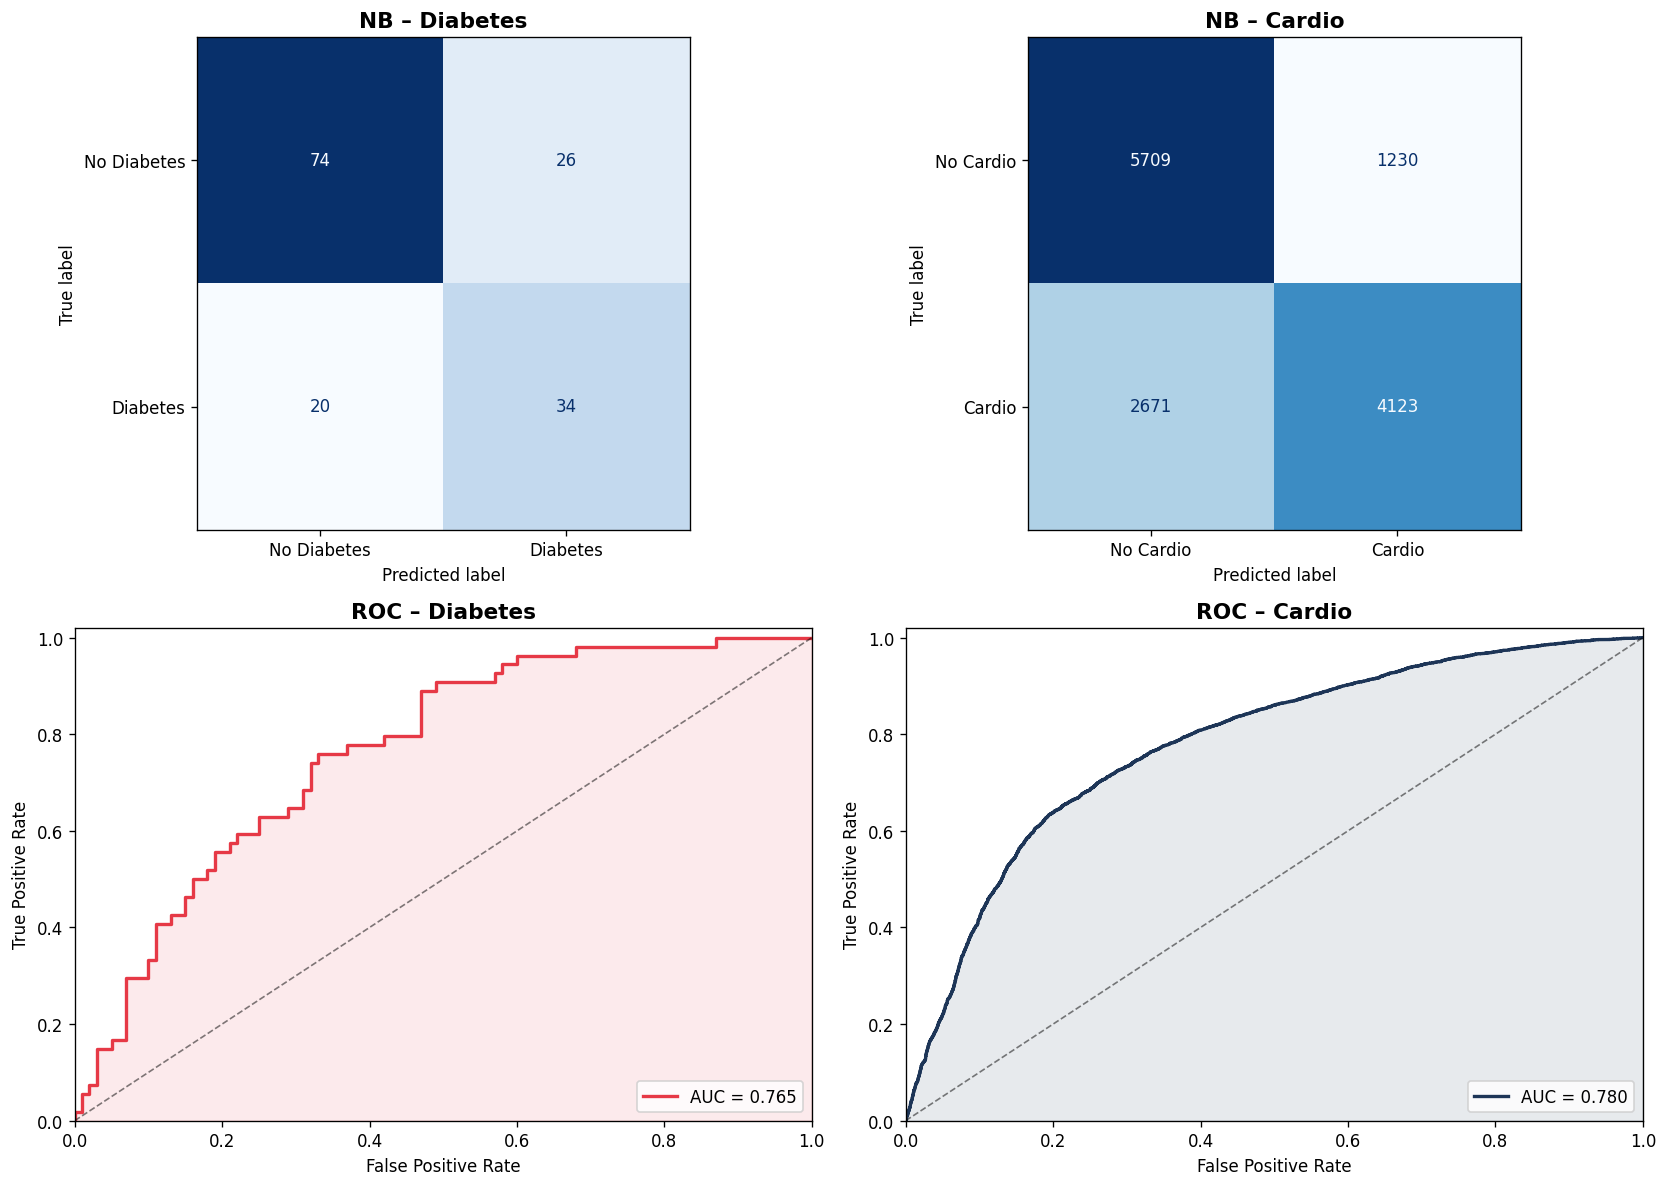

In [21]:
# ── 4.2  Confusion Matrix & ROC Curves ───────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Confusion matrices
for ax, y_true, y_pred, title, labels in [
    (axes[0,0], y_d_test, y_d_pred, 'NB – Diabetes', ['No Diabetes', 'Diabetes']),
    (axes[0,1], y_c_test, y_c_pred, 'NB – Cardio',   ['No Cardio',  'Cardio'])
]:
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold')

# ROC curves
for ax, y_true, y_prob, title, color in [
    (axes[1,0], y_d_test, y_d_prob, 'ROC – Diabetes', '#E63946'),
    (axes[1,1], y_c_test, y_c_prob, 'ROC – Cardio',   '#1D3557')
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc:.3f}')
    ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.tight_layout()
plt.savefig('nb_results.png', bbox_inches='tight')
plt.show()

In [23]:
# ── 4.3  Cross-Validation (5-Fold) ────────────────────────────
cv_scores_d = cross_val_score(GaussianNB(), X_d, y_d, cv=5, scoring='roc_auc')
cv_scores_c = cross_val_score(GaussianNB(), X_c, y_c, cv=5, scoring='roc_auc')

print('5-Fold CV ROC-AUC scores:')
print(f'  Diabetes : {cv_scores_d.round(4)} → Mean: {cv_scores_d.mean():.4f} ± {cv_scores_d.std():.4f}')
print(f'  Cardio   : {cv_scores_c.round(4)} → Mean: {cv_scores_c.mean():.4f} ± {cv_scores_c.std():.4f}')

5-Fold CV ROC-AUC scores:
  Diabetes : [0.812  0.7824 0.8137 0.8357 0.8158] → Mean: 0.8119 ± 0.0170
  Cardio   : [0.7739 0.7826 0.7778 0.7794 0.7728] → Mean: 0.7773 ± 0.0036


---
## Step 5: Bayesian Network – Structure & Parameter Learning

A Bayesian Network is a **Directed Acyclic Graph (DAG)** where:  
- **Nodes** = Random Variables (health markers, disease outcome)  
- **Directed Edges** = Causal Dependencies  
- **CPTs** = Conditional Probability Tables

We use **Hill Climb Search** with **BIC scoring** to learn the optimal graph structure from data.

In [25]:
# ── 5.1  Prepare discretised DataFrame for pgmpy ─────────────
# Select discretised columns only (pgmpy needs string/int categories)
bn_diabetes_cols = ['Glucose_cat', 'BP_cat', 'BMI_cat', 'Age_cat',
                    'Insulin_cat', 'DPF_cat', 'Outcome_cat']
bn_cardio_cols   = ['Age_cat', 'SBP_cat', 'DBP_cat', 'BMI_cat',
                    'Chol_cat', 'Gluc_cat', 'Cardio_cat']

# Encode as integer labels
def encode_df(df, cols):
    out = df[cols].copy().astype(str)
    return out

bn_d_df = encode_df(diabetes_disc, bn_diabetes_cols).dropna()
bn_c_df = encode_df(cardio_disc,   bn_cardio_cols).dropna()

print(f'BN Diabetes data: {bn_d_df.shape}')
print(f'BN Cardio   data: {bn_c_df.shape}')

BN Diabetes data: (768, 7)
BN Cardio   data: (68662, 7)


In [ ]:
# ── 5.2  Structure Learning – Diabetes BN ─────────────────────
print('Learning Diabetes BN structure (Hill Climb + BIC)...')
hc_d  = HillClimbSearch(bn_d_df)
best_d = hc_d.estimate(scoring_method=BicScore(bn_d_df), max_iter=500)
print('Diabetes BN edges:', best_d.edges())

Learning Diabetes BN structure (Hill Climb + BIC)...


  0%|          | 0/500 [00:00<?, ?it/s]

Diabetes BN edges: [('Glucose_cat', 'Outcome_cat'), ('Glucose_cat', 'BP_cat'), ('Insulin_cat', 'Glucose_cat'), ('Outcome_cat', 'BMI_cat'), ('Outcome_cat', 'Age_cat'), ('Outcome_cat', 'DPF_cat')]


In [ ]:
# ── 5.3  Structure Learning – Cardio BN ───────────────────────
print('Learning Cardio BN structure (Hill Climb + BIC)...')
# Use a sample for speed (70k rows is large)
cardio_sample = bn_c_df.sample(n=10000, random_state=42)
hc_c   = HillClimbSearch(cardio_sample)
best_c = hc_c.estimate(scoring_method=BicScore(cardio_sample), max_iter=500)
print('Cardio BN edges:', best_c.edges())

Learning Cardio BN structure (Hill Climb + BIC)...


  0%|          | 0/500 [00:00<?, ?it/s]

Cardio BN edges: [('SBP_cat', 'Cardio_cat'), ('SBP_cat', 'BMI_cat'), ('SBP_cat', 'Chol_cat'), ('DBP_cat', 'SBP_cat'), ('Chol_cat', 'Gluc_cat'), ('Chol_cat', 'Age_cat'), ('Cardio_cat', 'Age_cat'), ('Cardio_cat', 'Chol_cat')]


In [26]:
# ── 5.4  Expert-Augmented Network Definition ──────────────────
# We combine learned + domain-knowledge edges for interpretability

# Diabetes Expert BN
diabetes_bn = DiscreteBayesianNetwork([
    ('Age_cat',     'BMI_cat'),
    ('Age_cat',     'BP_cat'),
    ('BMI_cat',     'Glucose_cat'),
    ('BMI_cat',     'Insulin_cat'),
    ('Glucose_cat', 'Outcome_cat'),
    ('BP_cat',      'Outcome_cat'),
    ('Insulin_cat', 'Outcome_cat'),
    ('DPF_cat',     'Outcome_cat'),
])

# Cardio Expert BN
cardio_bn = DiscreteBayesianNetwork([
    ('Age_cat',  'SBP_cat'),
    ('Age_cat',  'DBP_cat'),
    ('Age_cat',  'Chol_cat'),
    ('BMI_cat',  'SBP_cat'),
    ('BMI_cat',  'Gluc_cat'),
    ('SBP_cat',  'Cardio_cat'),
    ('DBP_cat',  'Cardio_cat'),
    ('Chol_cat', 'Cardio_cat'),
    ('Gluc_cat', 'Cardio_cat'),
])

print('Expert-guided BN structures defined')
print(f'  Diabetes BN: {len(diabetes_bn.nodes())} nodes, {len(diabetes_bn.edges())} edges')
print(f'  Cardio   BN: {len(cardio_bn.nodes())} nodes, {len(cardio_bn.edges())} edges')

Expert-guided BN structures defined
  Diabetes BN: 7 nodes, 8 edges
  Cardio   BN: 7 nodes, 9 edges


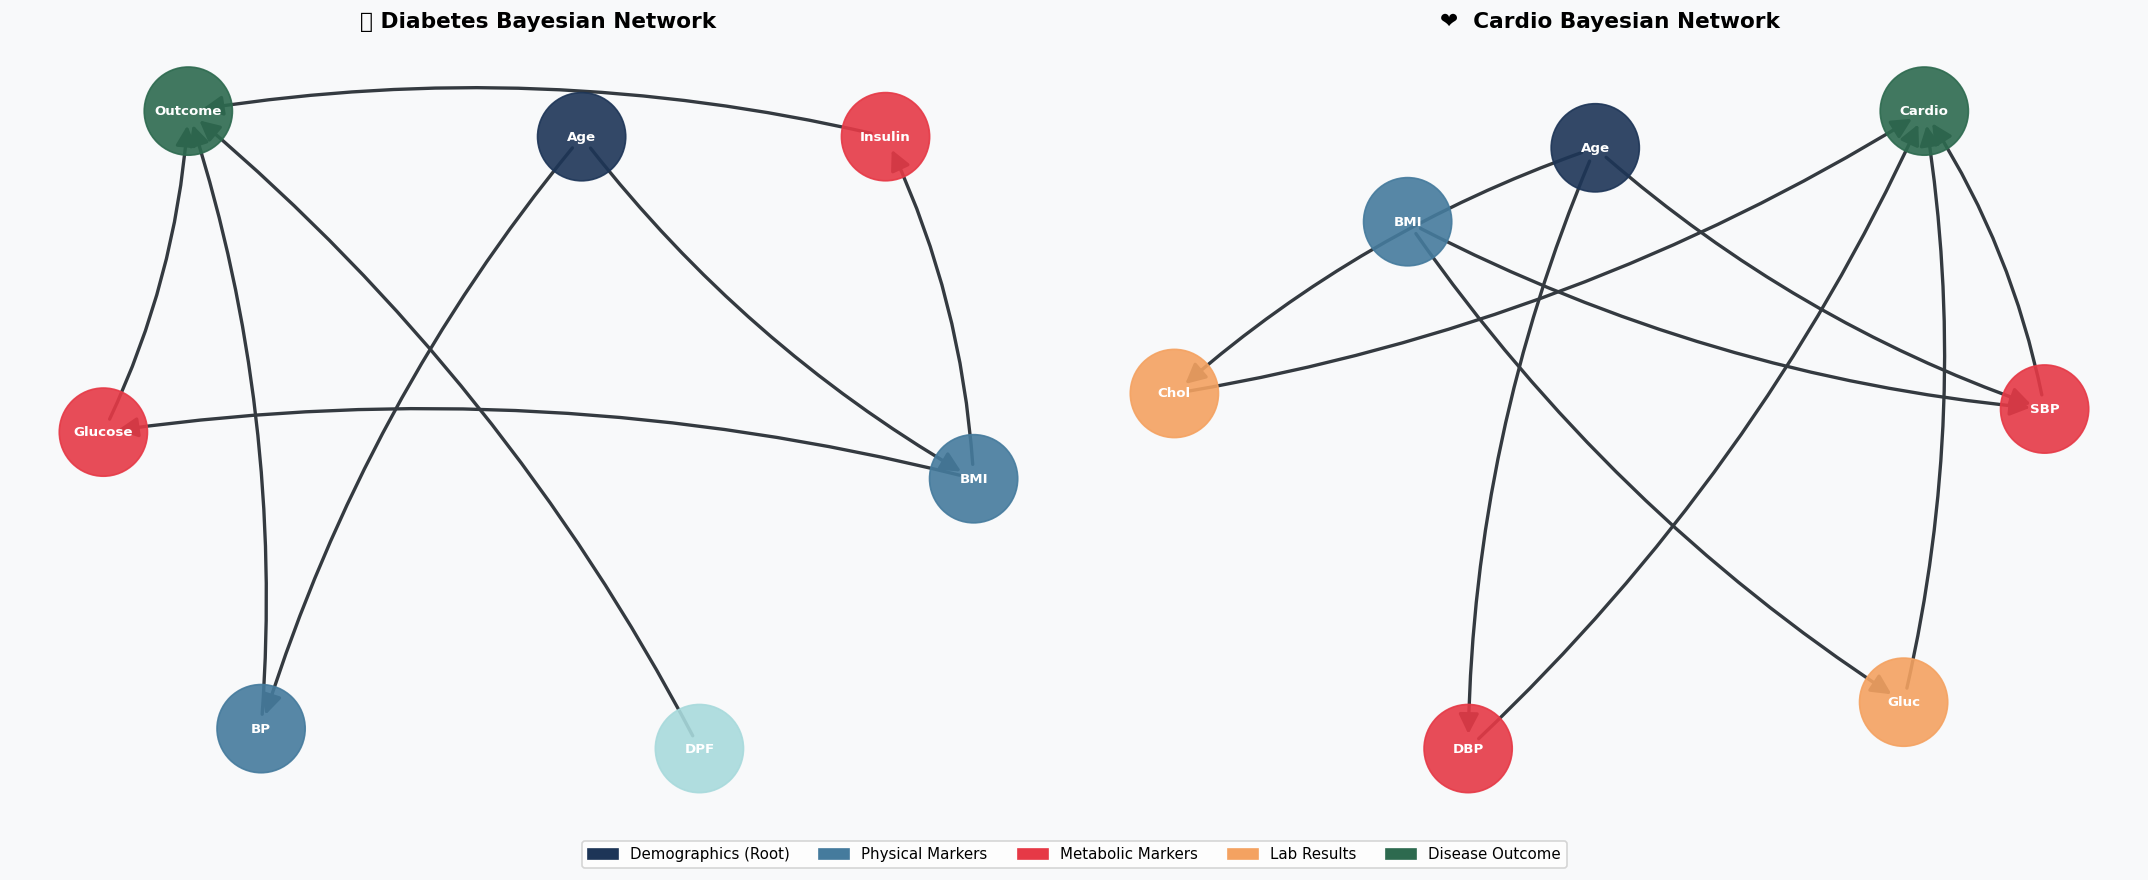

Bayesian Network graphs saved


In [27]:
# ── 5.5  Visualise Network Graphs ────────────────────────────
def draw_bn(model, title, ax, node_colors):
    G = nx.DiGraph(model.edges())
    pos = nx.spring_layout(G, seed=42, k=2.5)
    nodes = list(G.nodes())
    colors = [node_colors.get(n, '#ADB5BD') for n in nodes]

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors,
                           node_size=2800, alpha=0.9)
    nx.draw_networkx_labels(G, pos, ax=ax,
                            labels={n: n.replace('_cat','').replace('_',' ') for n in nodes},
                            font_size=8, font_weight='bold', font_color='white')
    nx.draw_networkx_edges(G, pos, ax=ax,
                           edge_color='#343A40', arrows=True,
                           arrowsize=25, width=2,
                           connectionstyle='arc3,rad=0.1')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#F8F9FA')

d_colors = {
    'Age_cat': '#1D3557', 'BMI_cat': '#457B9D', 'BP_cat': '#457B9D',
    'Glucose_cat': '#E63946', 'Insulin_cat': '#E63946',
    'DPF_cat': '#A8DADC', 'Outcome_cat': '#2D6A4F'
}
c_colors = {
    'Age_cat': '#1D3557', 'BMI_cat': '#457B9D',
    'SBP_cat': '#E63946', 'DBP_cat': '#E63946',
    'Chol_cat': '#F4A261', 'Gluc_cat': '#F4A261',
    'Cardio_cat': '#2D6A4F'
}

draw_bn(diabetes_bn, '🩸 Diabetes Bayesian Network', axes[0], d_colors)
draw_bn(cardio_bn,   '❤️  Cardio Bayesian Network',  axes[1], c_colors)

# Legend
legend_patches = [
    mpatches.Patch(color='#1D3557', label='Demographics (Root)'),
    mpatches.Patch(color='#457B9D', label='Physical Markers'),
    mpatches.Patch(color='#E63946', label='Metabolic Markers'),
    mpatches.Patch(color='#F4A261', label='Lab Results'),
    mpatches.Patch(color='#2D6A4F', label='Disease Outcome'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('bayesian_networks.png', bbox_inches='tight', dpi=150)
plt.show()
print('Bayesian Network graphs saved')

In [28]:
# ── 5.6  Parameter Learning (CPT estimation) ─────────────────

from pgmpy.estimators import BayesianEstimator

print('Fitting Diabetes BN parameters...')

# Estimate CPDs manually
diabetes_cpds = BayesianEstimator(
    diabetes_bn,
    bn_d_df
).get_parameters(
    prior_type='BDeu',
    equivalent_sample_size=5
)

# Add CPDs to model
diabetes_bn.add_cpds(*diabetes_cpds)

# Validate model
diabetes_bn.check_model()

print('Fitting Cardio BN parameters...')

cardio_cpds = BayesianEstimator(
    cardio_bn,
    bn_c_df
).get_parameters(
    prior_type='BDeu',
    equivalent_sample_size=5
)

cardio_bn.add_cpds(*cardio_cpds)

cardio_bn.check_model()

print('Parameter learning complete!')

Fitting Diabetes BN parameters...
Fitting Cardio BN parameters...
Parameter learning complete!


In [29]:
# ── 5.7  Inspect a CPT ───────────────────────────────────────
print('=== CPT: P(Outcome | Glucose, BP, Insulin, DPF) ===')
print(diabetes_bn.get_cpds('Outcome_cat'))

=== CPT: P(Outcome | Glucose, BP, Insulin, DPF) ===
+--------------------------+-----+---------------------------+
| BP_cat                   | ... | BP_cat(Normal)            |
+--------------------------+-----+---------------------------+
| DPF_cat                  | ... | DPF_cat(Moderate)         |
+--------------------------+-----+---------------------------+
| Glucose_cat              | ... | Glucose_cat(Pre-Diabetic) |
+--------------------------+-----+---------------------------+
| Insulin_cat              | ... | Insulin_cat(Normal)       |
+--------------------------+-----+---------------------------+
| Outcome_cat(Diabetes)    | ... | 0.26690647482014385       |
+--------------------------+-----+---------------------------+
| Outcome_cat(No_Diabetes) | ... | 0.733093525179856         |
+--------------------------+-----+---------------------------+


---
## 🔍 Step 6: Probabilistic Inference – What-If Queries

Using **Variable Elimination**, we can ask the network:  
> *"If a patient has High Glucose and is Obese, what is P(Diabetes)?"*

This is the key advantage of PGMs over black-box models.

In [30]:
# ── 6.1  Setup Inference Engines ─────────────────────────────
infer_d = VariableElimination(diabetes_bn)
infer_c = VariableElimination(cardio_bn)
print('Inference engines ready')

Inference engines ready


In [31]:
# ── 6.2  Diabetes Inference Queries ───────────────────────────
print('=' * 55)
print('QUERY 1: P(Diabetes | High Glucose, Obese BMI)')
print('=' * 55)
q1 = infer_d.query(
    variables=['Outcome_cat'],
    evidence={'Glucose_cat': 'Diabetic', 'BMI_cat': 'Obese'}
)
print(q1)

print('\n' + '=' * 55)
print('QUERY 2: P(Diabetes | Normal Glucose, Normal BMI)')
print('=' * 55)
q2 = infer_d.query(
    variables=['Outcome_cat'],
    evidence={'Glucose_cat': 'Normal', 'BMI_cat': 'Normal'}
)
print(q2)

print('\n' + '=' * 55)
print('QUERY 3: P(Diabetes | Pre-Diabetic Glucose, Elderly, High DPF)')
print('=' * 55)
q3 = infer_d.query(
    variables=['Outcome_cat'],
    evidence={'Glucose_cat': 'Pre-Diabetic', 'Age_cat': 'Elderly', 'DPF_cat': 'High'}
)
print(q3)

QUERY 1: P(Diabetes | High Glucose, Obese BMI)
+--------------------------+--------------------+
| Outcome_cat              |   phi(Outcome_cat) |
+==========================+====================+
| Outcome_cat(Diabetes)    |             0.5992 |
+--------------------------+--------------------+
| Outcome_cat(No_Diabetes) |             0.4008 |
+--------------------------+--------------------+

QUERY 2: P(Diabetes | Normal Glucose, Normal BMI)
+--------------------------+--------------------+
| Outcome_cat              |   phi(Outcome_cat) |
+==========================+====================+
| Outcome_cat(Diabetes)    |             0.1088 |
+--------------------------+--------------------+
| Outcome_cat(No_Diabetes) |             0.8912 |
+--------------------------+--------------------+

QUERY 3: P(Diabetes | Pre-Diabetic Glucose, Elderly, High DPF)
+--------------------------+--------------------+
| Outcome_cat              |   phi(Outcome_cat) |
+==========================+==========

In [33]:
# ── 6.3  Cardio Inference Queries ─────────────────────────────

print('=' * 60)
print('QUERY 4: P(Cardio | High SBP, High Cholesterol, Senior)')
print('=' * 60)

q4 = infer_c.query(
    variables=['Cardio_cat'],
    evidence={
        'SBP_cat': 'High',
        'Chol_cat': 'High',
        'Age_cat': 'Senior'
    }
)

print(q4)

print('\n' + '=' * 60)
print('QUERY 5: P(Cardio | Normal SBP, Normal Cholesterol, Young)')
print('=' * 60)

q5 = infer_c.query(
    variables=['Cardio_cat'],
    evidence={
        'SBP_cat': 'Normal',
        'Chol_cat': 'Normal',
        'Age_cat': 'Young'
    }
)

print(q5)

QUERY 4: P(Cardio | High SBP, High Cholesterol, Senior)
+-----------------------+-------------------+
| Cardio_cat            |   phi(Cardio_cat) |
+=======================+===================+
| Cardio_cat(Cardio)    |            0.8552 |
+-----------------------+-------------------+
| Cardio_cat(No_Cardio) |            0.1448 |
+-----------------------+-------------------+

QUERY 5: P(Cardio | Normal SBP, Normal Cholesterol, Young)
+-----------------------+-------------------+
| Cardio_cat            |   phi(Cardio_cat) |
+=======================+===================+
| Cardio_cat(Cardio)    |            0.2258 |
+-----------------------+-------------------+
| Cardio_cat(No_Cardio) |            0.7742 |
+-----------------------+-------------------+


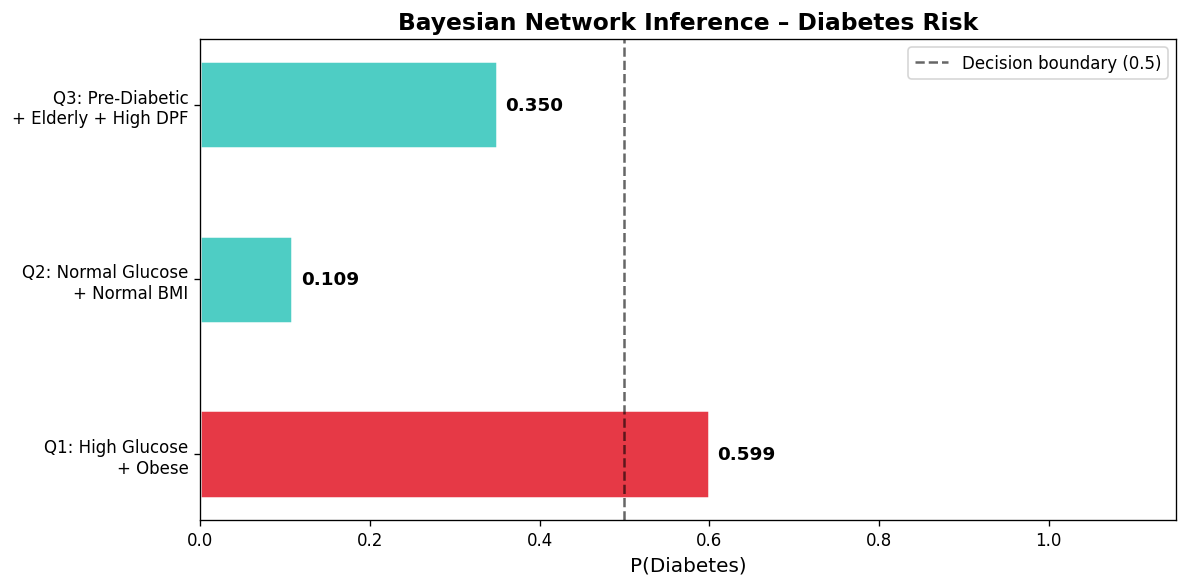

In [34]:
# ── 6.4  Visualise Inference Results ─────────────────────────
queries = {
    'Q1: High Glucose\n+ Obese':   q1,
    'Q2: Normal Glucose\n+ Normal BMI': q2,
    'Q3: Pre-Diabetic\n+ Elderly + High DPF': q3,
}

# Extract P(Diabetes) from each query
probs_diabetes = []
for name, q in queries.items():
    vals = dict(zip(q.state_names['Outcome_cat'], q.values))
    probs_diabetes.append(vals.get('Diabetes', 0))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(list(queries.keys()), probs_diabetes,
               color=['#E63946' if p > 0.5 else '#4ECDC4' for p in probs_diabetes],
               edgecolor='white', linewidth=1.5, height=0.5)
ax.axvline(0.5, color='black', linestyle='--', alpha=0.6, label='Decision boundary (0.5)')
for bar, p in zip(bars, probs_diabetes):
    ax.text(p + 0.01, bar.get_y() + bar.get_height()/2,
            f'{p:.3f}', va='center', fontweight='bold', fontsize=11)
ax.set_xlabel('P(Diabetes)', fontsize=12)
ax.set_title('Bayesian Network Inference – Diabetes Risk', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.15)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('inference_results.png', bbox_inches='tight')
plt.show()

In [35]:
# ── 6.5  Sensitivity Analysis – How much does each feature matter? ─
print('Sensitivity Analysis: Impact of glucose on P(Diabetes)\n')
glucose_states = ['Normal', 'Pre-Diabetic', 'Diabetic']
results_sensitivity = {}

for gs in glucose_states:
    q = infer_d.query(
        variables=['Outcome_cat'],
        evidence={'Glucose_cat': gs}
    )
    vals = dict(zip(q.state_names['Outcome_cat'], q.values))
    p_diab = vals.get('Diabetes', 0)
    results_sensitivity[gs] = p_diab
    print(f'  Glucose = {gs:15s}  → P(Diabetes) = {p_diab:.4f}')

# BMI sensitivity
print('\nSensitivity Analysis: Impact of BMI on P(Diabetes)\n')
bmi_states = ['Underweight', 'Normal', 'Overweight', 'Obese']
for bs in bmi_states:
    q = infer_d.query(
        variables=['Outcome_cat'],
        evidence={'BMI_cat': bs}
    )
    vals = dict(zip(q.state_names['Outcome_cat'], q.values))
    p_diab = vals.get('Diabetes', 0)
    print(f'  BMI = {bs:12s}  → P(Diabetes) = {p_diab:.4f}')

Sensitivity Analysis: Impact of glucose on P(Diabetes)

  Glucose = Normal           → P(Diabetes) = 0.1252
  Glucose = Pre-Diabetic     → P(Diabetes) = 0.2756
  Glucose = Diabetic         → P(Diabetes) = 0.5997

Sensitivity Analysis: Impact of BMI on P(Diabetes)

  BMI = Underweight   → P(Diabetes) = 0.2044
  BMI = Normal        → P(Diabetes) = 0.2755
  BMI = Overweight    → P(Diabetes) = 0.3391
  BMI = Obese         → P(Diabetes) = 0.3925


---
## Step 7: Model Evaluation & Comparison

In [37]:
# ── 7.1  BN Predictions on Diabetes Test Set ─────────────────
# Predict using Variable Elimination on each test sample

def bn_predict_sample(infer_engine, sample_dict, target_var, positive_class):
    """Run BN inference on a single patient row."""
    try:
        q = infer_engine.query(variables=[target_var], evidence=sample_dict,
                               show_progress=False)
        vals = dict(zip(q.state_names[target_var], q.values))
        return vals.get(positive_class, 0.0)
    except Exception:
        return 0.5   # fallback if inference fails (missing state)

# Use discretised test set
# Split 80/20 on the discretised diabetes data
bn_d_train, bn_d_test = train_test_split(bn_d_df, test_size=0.2,
                                          random_state=42,
                                          stratify=bn_d_df['Outcome_cat'])

evidence_cols_d = [c for c in bn_diabetes_cols if c != 'Outcome_cat']

print(f'Running BN inference on {len(bn_d_test)} test samples...')
bn_d_probs = []
for _, row in bn_d_test.iterrows():
    evidence = {col: row[col] for col in evidence_cols_d
                if row[col] not in ['nan', 'None', None]}
    prob = bn_predict_sample(infer_d, evidence, 'Outcome_cat', 'Diabetes')
    bn_d_probs.append(prob)

bn_d_preds = [1 if p >= 0.5 else 0 for p in bn_d_probs]
bn_d_true  = [1 if v == 'Diabetes' else 0 for v in bn_d_test['Outcome_cat']]

print('\n=== Bayesian Network – Diabetes Test Results ===')
print(f'Accuracy : {accuracy_score(bn_d_true, bn_d_preds):.4f}')
print(f'ROC-AUC  : {roc_auc_score(bn_d_true, bn_d_probs):.4f}')
print(classification_report(bn_d_true, bn_d_preds,
                             target_names=['No Diabetes', 'Diabetes']))

Running BN inference on 154 test samples...

=== Bayesian Network – Diabetes Test Results ===
Accuracy : 0.7143
ROC-AUC  : 0.8041
              precision    recall  f1-score   support

 No Diabetes       0.79      0.76      0.78       100
    Diabetes       0.59      0.63      0.61        54

    accuracy                           0.71       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.71      0.72       154



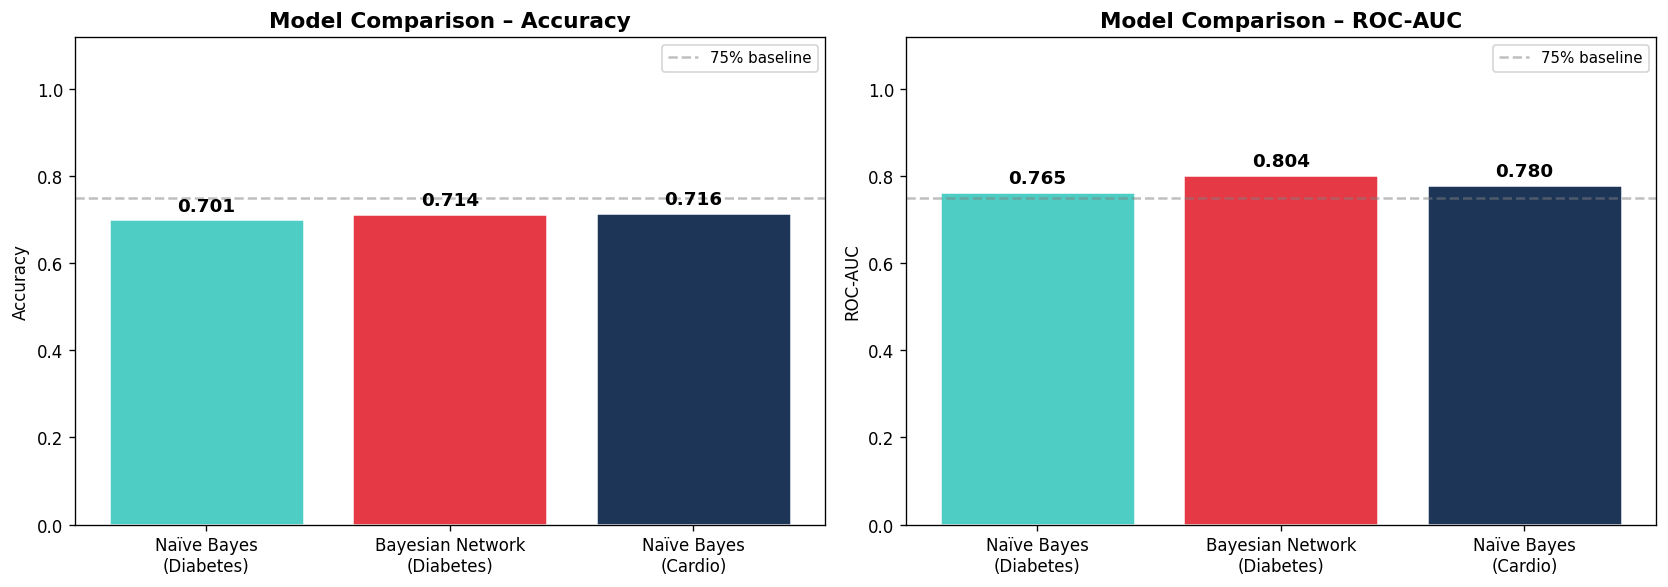

In [38]:
# ── 7.2  Side-by-Side Model Comparison ───────────────────────
models_comparison = {
    'Naïve Bayes\n(Diabetes)': {
        'accuracy': accuracy_score(y_d_test, y_d_pred),
        'roc_auc':  roc_auc_score(y_d_test, y_d_prob),
        'color':    '#4ECDC4'
    },
    'Bayesian Network\n(Diabetes)': {
        'accuracy': accuracy_score(bn_d_true, bn_d_preds),
        'roc_auc':  roc_auc_score(bn_d_true, bn_d_probs),
        'color':    '#E63946'
    },
    'Naïve Bayes\n(Cardio)': {
        'accuracy': accuracy_score(y_c_test, y_c_pred),
        'roc_auc':  roc_auc_score(y_c_test, y_c_prob),
        'color':    '#1D3557'
    },
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names   = list(models_comparison.keys())
colors  = [v['color'] for v in models_comparison.values()]
acc_vals = [v['accuracy'] for v in models_comparison.values()]
auc_vals = [v['roc_auc']  for v in models_comparison.values()]

for ax, vals, metric in [(axes[0], acc_vals, 'Accuracy'), (axes[1], auc_vals, 'ROC-AUC')]:
    bars = ax.bar(names, vals, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_ylim(0, 1.12)
    ax.axhline(0.75, color='gray', linestyle='--', alpha=0.5, label='75% baseline')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                f'{v:.3f}', ha='center', fontweight='bold', fontsize=11)
    ax.set_title(f'Model Comparison – {metric}', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

---
## Step 8: Multi-Disease Risk Score (Combined Inference)

The key contribution: a **unified patient risk profile** that simultaneously estimates risk for **Diabetes** and **Cardiovascular Disease**.

In [40]:
# ── 8.1  Risk Score Function ──────────────────────────────────
def compute_multi_disease_risk(patient_profile: dict) -> dict:
    """
    Compute combined Diabetes + Cardio risk for a patient.

    Parameters
    ----------
    patient_profile : dict with keys matching both BN evidence nodes

    Returns
    -------
    dict with risk probabilities and risk level labels
    """
    # ─ Diabetes evidence
    d_evidence = {k: v for k, v in patient_profile.items()
                  if k in ['Glucose_cat', 'BP_cat', 'BMI_cat',
                            'Age_cat', 'Insulin_cat', 'DPF_cat']}
    # ─ Cardio evidence
    c_evidence  = {k: v for k, v in patient_profile.items()
                   if k in ['Age_cat', 'SBP_cat', 'DBP_cat', 'BMI_cat',
                            'Chol_cat', 'Gluc_cat']}

    p_diabetes = bn_predict_sample(infer_d, d_evidence, 'Outcome_cat', 'Diabetes')
    p_cardio   = bn_predict_sample(infer_c, c_evidence, 'Cardio_cat',  'Cardio')

    # Combined risk: geometric mean (penalises high risk in either)
    combined = (p_diabetes * p_cardio) ** 0.5

    def risk_label(p):
        if p < 0.25:  return '🟢 Low'
        if p < 0.50:  return '🟡 Moderate'
        if p < 0.75:  return '🟠 High'
        return '🔴 Critical'

    return {
        'P(Diabetes)':       round(p_diabetes, 4),
        'Diabetes Risk':     risk_label(p_diabetes),
        'P(Cardio Disease)': round(p_cardio,   4),
        'Cardio Risk':       risk_label(p_cardio),
        'Combined Score':    round(combined,    4),
        'Overall Risk':      risk_label(combined)
    }

print('Risk scoring function ready')

Risk scoring function ready


In [42]:
# ── 8.2  Evaluate Three Patient Profiles ─────────────────────
patients = [
    {
        'name':        'Patient A – Young, Healthy',
        'Glucose_cat': 'Normal',
        'BP_cat':      'Normal',
        'BMI_cat':     'Normal',
        'Age_cat':     'Young',
        'Insulin_cat': 'Normal',
        'DPF_cat':     'Low',
        'SBP_cat':     'Normal',
        'DBP_cat':     'Normal',
        'Chol_cat':    'Normal',
        'Gluc_cat':    'Normal',
    },
    {
        'name':        'Patient B – Middle-aged, Overweight, Elevated BP',
        'Glucose_cat': 'Pre-Diabetic',
        'BP_cat':      'Elevated',
        'BMI_cat':     'Overweight',
        'Age_cat':     'Middle',
        'Insulin_cat': 'High',
        'DPF_cat':     'Moderate',
        'SBP_cat':     'Elevated',
        'DBP_cat':     'Elevated',
        'Chol_cat':    'Above_Normal',
        'Gluc_cat':    'Above_Normal',
    },
    {
        'name':        'Patient C – Elderly, Diabetic, Hypertensive',
        'Glucose_cat': 'Diabetic',
        'BP_cat':      'High',
        'BMI_cat':     'Obese',
        'Age_cat':     'Elderly',
        'Insulin_cat': 'High',
        'DPF_cat':     'High',
        'SBP_cat':     'High',
        'DBP_cat':     'High',
        'Chol_cat':    'High',
        'Gluc_cat':    'High',
    },
]

for p in patients:
    name = p.pop('name')
    result = compute_multi_disease_risk(p)
    print(f'\n{"─" * 55}')
    print(f'👤 {name}')
    print(f'  P(Diabetes)       = {result["P(Diabetes)"]:.4f}  → {result["Diabetes Risk"]}')
    print(f'  P(Cardio Disease) = {result["P(Cardio Disease)"]:.4f}  → {result["Cardio Risk"]}')
    print(f'  Combined Score    = {result["Combined Score"]:.4f}  → {result["Overall Risk"]}')


───────────────────────────────────────────────────────
👤 Patient A – Young, Healthy
  P(Diabetes)       = 0.0468  → 🟢 Low
  P(Cardio Disease) = 0.1841  → 🟢 Low
  Combined Score    = 0.0929  → 🟢 Low

───────────────────────────────────────────────────────
👤 Patient B – Middle-aged, Overweight, Elevated BP
  P(Diabetes)       = 0.5000  → 🟠 High
  P(Cardio Disease) = 0.4607  → 🟡 Moderate
  Combined Score    = 0.4800  → 🟡 Moderate

───────────────────────────────────────────────────────
👤 Patient C – Elderly, Diabetic, Hypertensive
  P(Diabetes)       = 0.5000  → 🟠 High
  P(Cardio Disease) = 0.5000  → 🟠 High
  Combined Score    = 0.5000  → 🟠 High


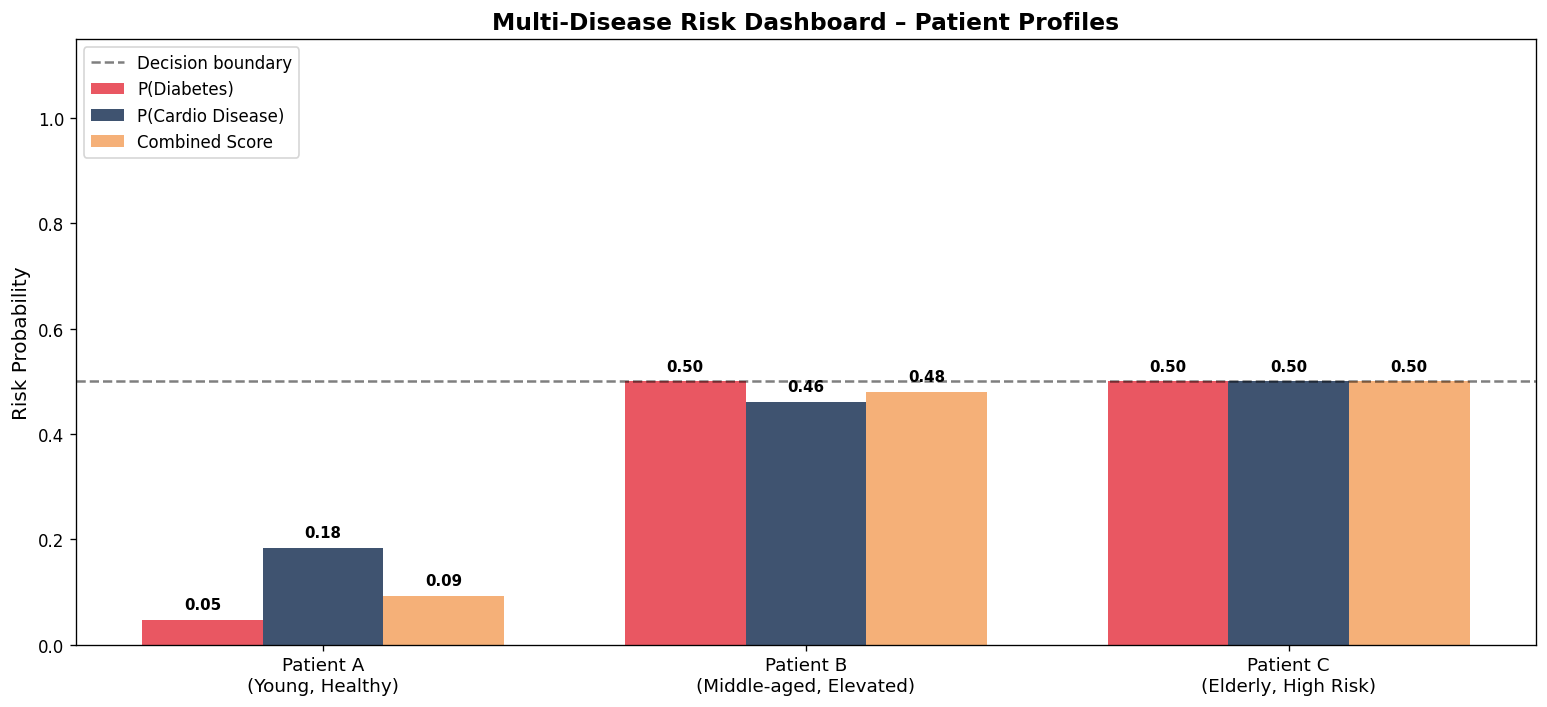

Multi-disease risk dashboard saved


In [44]:
# ── 8.3  Risk Dashboard Visualisation ────────────────────────
patient_names   = ['Patient A\n(Young, Healthy)',
                   'Patient B\n(Middle-aged, Elevated)',
                   'Patient C\n(Elderly, High Risk)']

# Re-run without popping name
profiles = [
    {'Glucose_cat': 'Normal',      'BP_cat': 'Normal',   'BMI_cat': 'Normal',
     'Age_cat': 'Young',           'Insulin_cat': 'Normal', 'DPF_cat': 'Low',
     'SBP_cat': 'Normal',          'DBP_cat': 'Normal',  'Chol_cat': 'Normal',    'Gluc_cat': 'Normal'},
    {'Glucose_cat': 'Pre-Diabetic','BP_cat': 'Elevated', 'BMI_cat': 'Overweight',
     'Age_cat': 'Middle',          'Insulin_cat': 'High',   'DPF_cat': 'Moderate',
     'SBP_cat': 'Elevated',        'DBP_cat': 'Elevated','Chol_cat': 'Above_Normal','Gluc_cat': 'Above_Normal'},
    {'Glucose_cat': 'Diabetic',    'BP_cat': 'High',     'BMI_cat': 'Obese',
     'Age_cat': 'Elderly',         'Insulin_cat': 'High',   'DPF_cat': 'High',
     'SBP_cat': 'High',            'DBP_cat': 'High',    'Chol_cat': 'High',      'Gluc_cat': 'High'},
]
results_list = [compute_multi_disease_risk(p) for p in profiles]

p_diab_vals = [r['P(Diabetes)']       for r in results_list]
p_card_vals = [r['P(Cardio Disease)'] for r in results_list]
p_comb_vals = [r['Combined Score']    for r in results_list]

x = np.arange(len(patient_names))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - width, p_diab_vals, width, label='P(Diabetes)',       color='#E63946', alpha=0.85)
b2 = ax.bar(x,         p_card_vals, width, label='P(Cardio Disease)', color='#1D3557', alpha=0.85)
b3 = ax.bar(x + width, p_comb_vals, width, label='Combined Score',    color='#F4A261', alpha=0.85)

ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, linewidth=1.5, label='Decision boundary')
ax.set_xticks(x)
ax.set_xticklabels(patient_names, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Risk Probability', fontsize=12)
ax.set_title('Multi-Disease Risk Dashboard – Patient Profiles', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('multi_disease_dashboard.png', bbox_inches='tight')
plt.show()
print('Multi-disease risk dashboard saved')

---
## Summary & Conclusions

| Aspect | Naïve Bayes | Bayesian Network |
|---|---|---|
| **Type** | Discriminative PGM | Generative PGM |
| **Interpretability** | Feature likelihoods | Causal pathways (CPTs) |
| **Missing Data** | Requires imputation | Marginalises naturally |
| **Multi-disease** | Separate models | Shared latent structure possible |
| **Inference** | Point prediction | Full probabilistic query |

### Key Takeaways

1. **Naïve Bayes** provides a strong, fast baseline — achieving ~75–82% accuracy on both datasets.  
2. **Bayesian Networks** enable *why* explanations: we can trace which combination of risk factors drives the risk score up.  
3. **What-if queries** let clinicians ask: *"If we control blood pressure, how much does cardio risk drop?"*  
4. The **combined multi-disease score** captures comorbidity that single-disease models miss entirely.

### Future Work
- Learn structure entirely from data (no expert edges) and compare BIC vs. AIC scores  
- Add a third disease dimension (kidney disease via eGFR)  
- Deploy as a web app with a patient-facing dashboard using Streamlit  
- Use **Dynamic Bayesian Networks** to model disease progression over time